# 05 — Feature extraction and corn-yield probes

The headline evaluation notebook. Extracts per-tile embeddings from four frozen visual encoders, aggregates them per (county, year), runs Ridge / LightGBM probes for corn yield under both temporal and spatial generalisation splits with bootstrap CIs, and trains a supervised end-to-end ConvLSTM as the supervised imagery comparator.

**Purpose / inputs / outputs / runtime**

- **Purpose:** put every frozen encoder through the same probe protocol so the comparison is fair, and quantify how each encoder + probe combination generalises out-of-sample.
- **Inputs:** `data/processed/county_index.parquet` (tile index from notebook 02), `data/processed/yield_county_year.parquet` (USDA labels), the Geo-SimCLR weights and band stats from notebook 04, plus the raw AG HDF5s.
- **Outputs:** per-tile feature `.npy` files in `data/processed/features/`, per-(fips, year) aggregated parquets in `data/processed/features/per_county_year/`, the headline `results/tables/corn_yield_stage1.parquet` results table, and the supervised ConvLSTM weights in `models/convlstm/`.
- **Runtime:** **GPU strongly recommended for production** (~2.5–4 h on 2 GPUs with AMP and DataParallel; the dominant cost is Prithvi feature extraction). Set `DEBUG = True` to run a CPU smoke test that subsamples to ~500 tiles and skips Prithvi + ConvLSTM (~5 min on a laptop).

**Encoders compared**

| Encoder | Pre-training | Bands consumed | Output dim | Source |
|---|---|---|---|---|
| **Geo-SimCLR ResNet-18 (ours)** | self-supervised on CropNet AG, 7 states $\times$ 2017–2021, temporal positives | 3 (B02 / B08 / B11) — exact training distribution | 512 | `models/geo_simclr_resnet18/geo_simclr_resnet18_best.pt` (notebook 04) |
| **Prithvi-EO-2.0-300M** | NASA + IBM HLS Landsat / Sentinel-2 SSL | 6 expected (B/G/R/NarrowNIR/SWIR1/SWIR2); we channel-pad zeros for the three missing bands — documented limitation | varies (CLS token) | HuggingFace `ibm-nasa-geospatial/Prithvi-EO-2.0-300M` via `terratorch` |
| **DINOv2-base** | LVD-142M natural RGB images SSL | 3 RGB slots — we feed AG bands as `(R ← B02, G ← B08, B ← B11)`, also a documented band-mismatch | 768 (CLS token) | timm `vit_base_patch14_dinov2.lvd142m` |
| **Random-init ResNet-18** | none | 3 (same as Geo-SimCLR) | 512 | sanity baseline — isolates whether Geo-SimCLR's SSL pre-training adds value over random conv features |

**Comparison framework**

The visual encoders are compared against the six hand-crafted NDVI baselines from `03_baselines_data.ipynb`. The strongest non-DL baseline is *state one-hot + year scalar + biweekly NDVI series* fed to LightGBM (20 features); that's the number Geo-SimCLR has to beat. The supervised end-to-end ConvLSTM (Section 7 below) is the supervised imagery comparator at the same input modality, following the `ConvLSTM` baseline in Lin et al.\ KDD 2024 (CropNet) and Khaki et al.\ Frontiers Plant Sci 2020.

**Outputs on disk**

| Path | Description | Used by |
|---|---|---|
| `data/processed/features/feature_index.parquet` | per-tile metadata index | this notebook |
| `data/processed/features/<encoder>.npy` | per-tile embeddings, shape `(n, D)` per encoder | this notebook |
| `data/processed/features/per_county_year/<encoder>.parquet` | aggregated `(fips, year, feat_*)` per encoder | probe cells, `06_visualize.ipynb`, `09_results.ipynb` |
| `models/convlstm/convlstm_best.pt` | best-validation-RMSE ConvLSTM weights | this notebook |
| `results/tables/corn_yield_stage1.parquet` | the headline R² / RMSE table (encoder × probe × split × with/without state+year, with bootstrap CIs) | `06_visualize.ipynb`, `09_results.ipynb` |
| `results/charts/encoder_comparison.png` | bar chart of test R² by encoder | `09_results.ipynb` |

**Throughput notes (lessons from the production run).** A first attempt with `NUM_WORKERS = 16` and `persistent_workers = True` hit a CPU-RAM blow-up under pinned memory; the safe configuration is `NUM_WORKERS = 8` with `persistent_workers = False` and the h5py chunk cache re-enabled at `rdcc_nbytes = 32 MB` (about 3–5× faster per-tile read than `rdcc_nbytes = 0`). Feature-extraction batch sizes are doubled per encoder when `MULTI_GPU = True` so DataParallel + AMP have something to chew on.

In [1]:
"""
Imports, paths, config.

DEBUG = True  -> tiny local CPU smoke test (~5 min, skips Prithvi + ConvLSTM).
DEBUG = False -> production GPU run (~3-5 h on 2 GPUs with AMP and DataParallel).
"""
DEBUG = False

import os, re, json, time, warnings
from pathlib import Path
from typing import Optional
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
warnings.filterwarnings("ignore")
# Silence the `torch.cuda.amp.autocast(args...)` FutureWarning that DataParallel emits from
# its own internal parallel_apply.py. We use the new torch.amp API for our own autocast calls;
# this one comes from a PyTorch upstream module we can't patch.
warnings.filterwarnings("ignore", message=r".*torch\.cuda\.amp\.autocast.*", category=FutureWarning)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr, spearmanr
import lightgbm as lgb

# ---- Paths ----
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = ROOT / "data" / "raw" / "cropnet"
DATA_PROC = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"
RESULTS_DIR = ROOT / "results"
FEATURES_DIR = DATA_PROC / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
(FEATURES_DIR / "per_county_year").mkdir(exist_ok=True)
(RESULTS_DIR / "tables").mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "charts").mkdir(parents=True, exist_ok=True)

# Inputs from earlier notebooks
COUNTY_INDEX_PATH       = DATA_PROC / "county_index.parquet"
CRD_PATH                = DATA_PROC / "crd_lookup.parquet"
YIELD_PATH              = DATA_PROC / "yield_county_year.parquet"
BIWEEKLY_NDVI_PATH      = DATA_PROC / "biweekly_ndvi.parquet"
BASELINE_FEATURES_PATH  = DATA_PROC / "baseline_features.parquet"
BASELINE_RESULTS_PATH   = RESULTS_DIR / "tables" / "baseline_yield_results.parquet"

GEOSIMCLR_BEST_PATH = MODELS_DIR / "geo_simclr_resnet18" / "geo_simclr_resnet18_best.pt"
GEOSIMCLR_BAND_STATS = MODELS_DIR / "geo_simclr_resnet18" / "band_stats.json"

# Outputs
FEATURE_INDEX_PATH = FEATURES_DIR / "feature_index.parquet"
FINAL_RESULTS_PATH = RESULTS_DIR / "tables" / "corn_yield_stage1.parquet"
CONVLSTM_BEST_PATH = MODELS_DIR / "convlstm" / "convlstm_best.pt"
CONVLSTM_BEST_PATH.parent.mkdir(parents=True, exist_ok=True)

# ---- Config ----
class Cfg:
    # Always evaluate on the full dataset (all years incl 2022, all states, all counties)
    EVAL_YEARS = list(range(2017, 2023))
    EVAL_STATES = ("IA", "IL", "IN", "MN", "NE", "OH", "SD")  # full seven-state scope

    # Splits (must match what nb 03 used)
    TIME_TRAIN_YEARS = (2017, 2018, 2019, 2020)
    TIME_VAL_YEAR    = 2021
    TIME_TEST_YEAR   = 2022
    COUNTY_TEST_FRAC = 0.2
    COUNTY_SEED      = 0
    BOOTSTRAP_N      = 200          # bootstrap resamples for CIs
    BOOTSTRAP_SEED   = 42

    # Feature-extraction batch sizes (per encoder). These are *global* batch sizes; DataParallel
    # splits them across visible GPUs, and AMP fp16 roughly halves activation memory, so the
    # per-GPU memory pressure stays mild even at the larger sizes below.
    BATCH_GEOSIMCLR = 512          # ResNet-18, ~11M params, inference-only
    BATCH_DINOV2    = 256          # ViT-base, ~86M params
    BATCH_PRITHVI   = 64           # ViT, ~300M params; conservative
    BATCH_RANDOM    = 512          # same backbone as Geo-SimCLR

    # Automatic Mixed Precision for feature extraction *and* ConvLSTM training. The forward pass
    # runs inside `torch.amp.autocast("cuda")`; for ConvLSTM we also use a GradScaler. Extraction
    # is inference-only so no scaler is needed there. No-op on CPU.
    USE_AMP = True

    if DEBUG:
        DEVICE = "cpu"
        SUBSAMPLE_TILES = 500       # for the per-encoder extraction
        NUM_WORKERS = 0
        SKIP_PRITHVI = True         # terratorch usually not installed locally
        SKIP_CONVLSTM = True        # too expensive for a CPU smoke test
        TAG = "debug"
    else:
        DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
        SUBSAMPLE_TILES = None      # use all tiles
        # NUM_WORKERS = 8 was the safe value here. NUM_WORKERS = 16 with persistent_workers and
        # pinned memory caused a CPU-RAM OOM at the seven-state scope; 8 + persistent_workers=False
        # is the stable recipe and the actual throughput knob is the h5py chunk cache (rdcc_nbytes
        # = 32 MB) set inside TileDataset and CountyYearTimeSeriesDataset.
        NUM_WORKERS = 8
        # MULTI_GPU = True wraps each encoder forward in nn.DataParallel so feature extraction
        # spans both GPUs. Halves Prithvi wall-time (the bottleneck) and helps the others a bit.
        # ConvLSTM training has its own DataParallel check below, so this flag is only consulted
        # by the extract_features helper.
        MULTI_GPU = True
        SKIP_PRITHVI = False
        SKIP_CONVLSTM = False
        TAG = "prod"

cfg = Cfg()

print(f"Mode             : {'DEBUG' if DEBUG else 'PRODUCTION'}")
print(f"Device           : {cfg.DEVICE}")
print(f"Subsample tiles  : {cfg.SUBSAMPLE_TILES}")
print(f"Skip Prithvi     : {cfg.SKIP_PRITHVI}")
print(f"Skip ConvLSTM    : {cfg.SKIP_CONVLSTM}")
print(f"Eval years       : {cfg.EVAL_YEARS}")
print(f"Eval states      : {cfg.EVAL_STATES}")
print(f"Time test year   : {cfg.TIME_TEST_YEAR}")
print(f"County test frac : {cfg.COUNTY_TEST_FRAC} (seed={cfg.COUNTY_SEED})")
print(f"AMP              : {getattr(cfg, 'USE_AMP', False)} (autocast for extraction + ConvLSTM training)")
print(f"MULTI_GPU        : {getattr(cfg, 'MULTI_GPU', False)} (DataParallel for extract_features)")
print(f"NUM_WORKERS      : {cfg.NUM_WORKERS}")
print(f"Batch sizes      : geo={cfg.BATCH_GEOSIMCLR} rnd={cfg.BATCH_RANDOM} dino={cfg.BATCH_DINOV2} prithvi={cfg.BATCH_PRITHVI}")

# Verify required inputs
for p in [COUNTY_INDEX_PATH, CRD_PATH, YIELD_PATH, BIWEEKLY_NDVI_PATH, BASELINE_FEATURES_PATH,
          GEOSIMCLR_BEST_PATH, GEOSIMCLR_BAND_STATS]:
    assert p.exists(), f"Missing required input: {p}"
print()
print("All required inputs found.")

torch.manual_seed(0); np.random.seed(0)

Mode             : PRODUCTION
Device           : cuda
Subsample tiles  : None
Skip Prithvi     : False
Skip ConvLSTM    : False
Eval years       : [2017, 2018, 2019, 2020, 2021, 2022]
Eval states      : ('IA', 'IL', 'IN', 'MN', 'NE', 'OH', 'SD')
Time test year   : 2022
County test frac : 0.2 (seed=0)
AMP              : True (autocast for extraction + ConvLSTM training)
MULTI_GPU        : True (DataParallel for extract_features)
NUM_WORKERS      : 8
Batch sizes      : geo=512 rnd=512 dino=256 prithvi=64

All required inputs found.


## 1. Build the per-tile evaluation index

Notebook 04 trained on 2017–2021 only so that 2022 stays unseen by the SSL backbone. Here we extract embeddings for *all* six years × all seven states × all biweeks × all grids; the probe cells below then partition them via:

- **Time split:** train 2017–2020 / val 2021 / test 2022 (matches the splits in `03_baselines_data.ipynb`).
- **County split:** held-out random 20 % of counties × all years (also matches notebook 03).

In [2]:
"""
Build the per-tile evaluation index. Each row is one (state, fips, year, biweek, grid_idx).
"""
ci = pd.read_parquet(COUNTY_INDEX_PATH)
print(f"county_index rows: {len(ci):,}")

# Cross-check that county_index has every state in cfg.EVAL_STATES (mirrors the safety check
# in notebook 03 cell 5 and notebook 04). A stale parquet covering fewer states than expected
# would otherwise produce a smaller-scope evaluation than intended without any error.
_ci_states = sorted(ci["state"].unique().tolist())
_missing_states = sorted(set(cfg.EVAL_STATES) - set(_ci_states))
print(f"county_index states              : {_ci_states}")
print(f"cfg.EVAL_STATES                  : {sorted(cfg.EVAL_STATES)}")
if _missing_states:
    print()
    print("=" * 80)
    print(f"[ERROR] county_index.parquet is MISSING {len(_missing_states)} state(s): {_missing_states}")
    print(f"        These states are in cfg.EVAL_STATES but not in county_index.")
    print(f"        Likely cause: stale county_index.parquet from an earlier scope.")
    print(f"        Fix: regenerate via notebook 02 with the current scope.")
    print("=" * 80)
    print()

# Filter to evaluation scope
ci_eval = ci[
    ci["year"].astype(int).isin(cfg.EVAL_YEARS) &
    ci["state"].isin(cfg.EVAL_STATES)
].copy()
print(f"after year + state filter: {len(ci_eval):,}")
print(f"  per-state county-biweek rows   : {ci_eval.groupby('state').size().to_dict()}")

# Expand to per-tile
records = []
for _, row in tqdm(ci_eval.iterrows(), total=len(ci_eval), desc="Expanding to per-tile"):
    fips = int(row["fips"])
    n_grids = int(row["n_grids"])
    for grid_idx in range(n_grids):
        records.append({
            "state": row["state"],
            "fips": fips,
            "year": int(row["year"]),
            "biweek": row["biweek"],
            "grid_idx": grid_idx,
            "h5_path": row["h5_path"],
        })
feature_index = pd.DataFrame(records)
print(f"\nTotal eval tiles: {len(feature_index):,}")
print(f"  by state: {feature_index.groupby('state').size().to_dict()}")
print(f"  by year : {feature_index.groupby('year').size().to_dict()}")

# Optional subsample for DEBUG
if cfg.SUBSAMPLE_TILES is not None:
    feature_index = feature_index.sample(n=cfg.SUBSAMPLE_TILES, random_state=0).reset_index(drop=True)
    print(f"\nDEBUG subsample to {len(feature_index):,} tiles.")
else:
    feature_index = feature_index.reset_index(drop=True)

# Save the index (shared across all encoders)
feature_index.to_parquet(FEATURE_INDEX_PATH, index=False)
print(f"\nSaved feature_index to {FEATURE_INDEX_PATH}")
feature_index.head(3)

county_index rows: 44,140
county_index states              : ['IA', 'IL', 'IN', 'MN', 'NE', 'OH', 'SD']
cfg.EVAL_STATES                  : ['IA', 'IL', 'IN', 'MN', 'NE', 'OH', 'SD']
after year + state filter: 44,140
  per-state county-biweek rows   : {'IA': 7128, 'IL': 7255, 'IN': 6624, 'MN': 5969, 'NE': 6404, 'OH': 6155, 'SD': 4605}


Expanding to per-tile: 100%|██████████| 44140/44140 [00:04<00:00, 10476.19it/s]



Total eval tiles: 852,726
  by state: {'IA': 93744, 'IL': 106866, 'IN': 58176, 'MN': 197887, 'NE': 146088, 'OH': 75098, 'SD': 174867}
  by year : {2017: 140359, 2018: 142848, 2019: 142848, 2020: 142794, 2021: 142673, 2022: 141204}

Saved feature_index to /nfs/roberts/project/cpsc4520/cpsc4520_ipp3/project-geospatial/data/processed/features/feature_index.parquet


,state,fips,year,biweek,grid_idx,h5_path
0,IA,19001,2017,2017-04-01,0,Sentinel-2 Imagery/data/AG/2017/IA/Agriculture...
1,IA,19001,2017,2017-04-01,1,Sentinel-2 Imagery/data/AG/2017/IA/Agriculture...
2,IA,19001,2017,2017-04-01,2,Sentinel-2 Imagery/data/AG/2017/IA/Agriculture...


## 2. Generic feature extraction infrastructure

A `TileDataset` that yields raw `uint8` tiles + a metadata index. We pair it with **per-encoder preprocessing functions** and a single `extract_features` helper that handles the forward pass loop, batching, and saving.

Same HDF5 OOM safeguards as nb 04: per-worker handle caching with `rdcc_nbytes=0`.

In [3]:
"""
Cell 3 — TileDataset + extract_features helper.
"""

class TileDataset(Dataset):
    """Yields (tile_uint8, idx) pairs for batched encoder forward.
    
    tile_uint8: (224, 224, 3) uint8 -- raw AG bands B02/B08/B11.
    idx       : integer offset into feature_index for re-aligning embeddings.
    
    Worker-safe: opens HDF5 handles lazily per worker; rdcc_nbytes=0 prevents the OOM
    cache leak that hit nb 04.
    """
    def __init__(self, feature_index_df, data_root):
        self._records = feature_index_df.to_dict("records")
        self.data_root = Path(data_root)
        self._handles = None
    def _get_handle(self, h5_path):
        if self._handles is None:
            self._handles = {}
        if h5_path not in self._handles:
            # h5py chunk cache. Feature extraction reads tiles sequentially in feature_index
            # order, so the access pattern is very cache-friendly. 32 MB per file x ~12 open
            # files per worker x 8 workers ~= 3 GB extra RAM, trivial on the eval machine, and
            # gives a roughly 3-5x speedup per-tile read vs rdcc_nbytes = 0. Each extraction
            # call uses non-persistent workers so the cache is released when it returns.
            self._handles[h5_path] = h5py.File(
                self.data_root / h5_path, "r",
                rdcc_nbytes=32 * 1024 * 1024,   # 32 MB chunk cache
                rdcc_nslots=1009,               # prime; default 521 -> bumped for better hit rate
                rdcc_w0=0.75,                   # preference for keeping recently used chunks
            )
        return self._handles[h5_path]
    def __len__(self):
        return len(self._records)
    def __getitem__(self, idx):
        rec = self._records[idx]
        f = self._get_handle(rec["h5_path"])
        try:
            tile = f[str(rec["fips"])][rec["biweek"]]["data"][rec["grid_idx"]]
            tile = np.array(tile, copy=True)  # ensure writable for downstream
        except Exception:
            tile = np.zeros((224, 224, 3), dtype=np.uint8)
        return torch.from_numpy(tile.astype(np.uint8)), idx
    def __getstate__(self):
        s = self.__dict__.copy()
        s["_handles"] = None
        return s


def extract_features(
    feature_index_df: pd.DataFrame,
    encoder: nn.Module,
    preprocess_fn,        # (B, H, W, 3) uint8 -> (B, C, 224, 224) float on encoder's device
    name: str,
    out_path: Path,
    device: str = "cpu",
    batch_size: int = 256,
    num_workers: int = 0,
) -> np.ndarray:
    """Run encoder over every tile in feature_index_df. Save (n, D) numpy array.

    encoder must be put in eval() mode and produce (B, D) outputs from (B, C, H, W) inputs.

    AMP: if cfg.USE_AMP and device == 'cuda', the forward pass is wrapped in
    torch.amp.autocast("cuda") for a ~2-3x speedup on GPU. Accuracy is preserved at the
    fp32 level for inference (no backprop, so no GradScaler is needed). Outputs are cast
    back to fp32 before numpy save so downstream probes see exactly the same dtype as before.
    """
    if out_path.exists() and not DEBUG:
        feats = np.load(out_path)
        if len(feats) == len(feature_index_df):
            print(f"[{name}] features already exist at {out_path} ({feats.shape}). Loading.")
            return feats
        else:
            print(f"[{name}] stale features ({len(feats)} vs {len(feature_index_df)} tiles). Re-extracting.")

    encoder = encoder.eval().to(device)

    # DataParallel across both GPUs for feature extraction. Halves the wall-time for the
    # heavy encoders (Prithvi especially). Inference-only so there's no gradient-sync cost.
    # Gated on cfg.MULTI_GPU AND >=2 visible CUDA devices.
    _mgpu_active = bool(getattr(cfg, "MULTI_GPU", False)) and (device == "cuda") and torch.cuda.device_count() >= 2
    if _mgpu_active and not isinstance(encoder, nn.DataParallel):
        encoder = nn.DataParallel(encoder)
        print(f"[{name}] wrapped in DataParallel across {torch.cuda.device_count()} GPUs")

    ds = TileDataset(feature_index_df, DATA_RAW)
    loader = DataLoader(
        ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers,
        pin_memory=(device == "cuda"),
        prefetch_factor=2 if num_workers > 0 else None,
        persistent_workers=False,   # extraction is one pass per encoder; no epoch loop to amortize spawn cost
    )

    _amp_active = bool(getattr(cfg, "USE_AMP", False)) and (device == "cuda")
    if _amp_active:
        print(f"[{name}] AMP enabled (torch.amp.autocast cuda)")

    all_feats = []
    t0 = time.time()
    with torch.no_grad():
        for tiles_uint8, _idx in tqdm(loader, desc=f"extract {name}", unit="batch"):
            x = preprocess_fn(tiles_uint8).to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=_amp_active):
                h = encoder(x)
            if isinstance(h, (tuple, list)):
                h = h[0]  # some models return (h, others)
            all_feats.append(h.detach().float().cpu().numpy())  # cast fp16 -> fp32 before numpy
    feats = np.concatenate(all_feats, axis=0)
    print(f"[{name}] features {feats.shape} in {time.time() - t0:.1f}s")

    np.save(out_path, feats)
    print(f"[{name}] saved to {out_path}")
    return feats

## 3. Encoder loaders + per-encoder preprocessing

Each encoder needs:
1. **Load weights** (frozen)
2. **Output 512-d / 768-d / etc. backbone feature vector** (no projection head, no classifier)
3. **Custom preprocessing** matching its training distribution

Critical detail: **always apply the same per-band normalization that the encoder saw during training.** For Geo-SimCLR this is `band_stats.json`. For Prithvi this is HLS band stats. For DINOv2 this is ImageNet stats (with the band-mismatch caveat).

In [4]:
"""
Cell 4 — Geo-SimCLR ResNet-18: load weights, build preprocessing.
"""
# Load band stats saved by nb 04
band_stats = json.loads(GEOSIMCLR_BAND_STATS.read_text())
GS_MEAN = torch.tensor(band_stats["mean"], dtype=torch.float32).view(1, 3, 1, 1)
GS_STD  = torch.tensor(band_stats["std"],  dtype=torch.float32).view(1, 3, 1, 1)
print(f"Geo-SimCLR band stats: mean={band_stats['mean']}, std={band_stats['std']}")

# Build encoder
geosimclr_encoder = torchvision.models.resnet18(weights=None)
geosimclr_encoder.fc = nn.Identity()

# Load best.pt -- it stores 'encoder_state' (resnet18 state_dict without fc)
state = torch.load(GEOSIMCLR_BEST_PATH, map_location="cpu", weights_only=False)
missing, unexpected = geosimclr_encoder.load_state_dict(state["encoder_state"], strict=False)
print(f"Geo-SimCLR loaded. missing={missing}, unexpected={unexpected}")
print(f"  Trained on {state['config'].get('TRAIN_YEARS', '?')}, last epoch loss = {state['train_log_summary'].get('loss', '?'):.4f}")

def preprocess_geosimclr(tiles_uint8):
    """tiles_uint8: torch.uint8 (B, 224, 224, 3) -> float (B, 3, 224, 224) z-scored with training band stats."""
    x = tiles_uint8.permute(0, 3, 1, 2).float() / 255.0
    return (x - GS_MEAN) / GS_STD


print()
print(f"Geo-SimCLR encoder params: {sum(p.numel() for p in geosimclr_encoder.parameters()):,}")

Geo-SimCLR band stats: mean=[0.5868273973464966, 0.6528728604316711, 0.3455141484737396], std=[0.24112601578235626, 0.21514543890953064, 0.19584284722805023]
Geo-SimCLR loaded. missing=[], unexpected=[]
  Trained on (2017, 2018, 2019, 2020, 2021), last epoch loss = 3.1013

Geo-SimCLR encoder params: 11,176,512


In [5]:
"""
Cell 5 — DINOv2: load via timm, RGB-feed our AG bands.

Documented limitation: DINOv2 was trained on natural RGB images. We feed our 3-channel AG
(B02 Blue, B08 NIR, B11 SWIR1) to its (R, G, B) input slots. This is the standard EO-paper
practice when applying ImageNet-pretrained backbones to satellite. ImageNet stats are used
for normalization (also imperfect, but consistent with how DINOv2 was trained).
"""
import timm

# DINOv2-base patch-14, 224x224 input. timm handles positional-embedding interpolation.
try:
    dinov2_encoder = timm.create_model(
        "vit_base_patch14_dinov2.lvd142m",
        pretrained=True,
        num_classes=0,        # remove classification head -> returns CLS token
        img_size=224,
    )
    print(f"DINOv2-base loaded. params: {sum(p.numel() for p in dinov2_encoder.parameters()):,}")
    DINOV2_AVAILABLE = True
except Exception as e:
    print(f"DINOv2 load FAILED: {e}")
    print("(If running locally, ensure 'timm' is installed and HuggingFace cache has access.)")
    DINOV2_AVAILABLE = False
    dinov2_encoder = None

# ImageNet normalization (DINOv2's training distribution)
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def preprocess_dinov2(tiles_uint8):
    """Apply ImageNet normalization to our AG bands as if they were RGB.
    Channel order: (R, G, B) <- (B02, B08, B11). Documented limitation.
    """
    x = tiles_uint8.permute(0, 3, 1, 2).float() / 255.0
    return (x - IMAGENET_MEAN) / IMAGENET_STD

DINOv2-base loaded. params: 85,724,928


In [6]:
"""
Cell 6 — Prithvi-EO-2.0-300M: load via terratorch.

Prithvi expects 6-band HLS input: (B02, B03, B04, B8A, B11, B12). We have 3 bands (B02, B08, B11).
We channel-pad zeros for B03, B04, B12 and use B08 (Wide NIR) as a proxy for B8A (Narrow NIR);
the centers are 30 nm apart so the proxy is acceptable.

Documented limitation: half of Prithvi's input bands are zero-padded; the architecture's
learned representation can't fully exploit its multi-spectral capacity.
"""
PRITHVI_AVAILABLE = False
prithvi_encoder = None
prithvi_load_error = None

if not cfg.SKIP_PRITHVI:
    # First check terratorch is importable at all (and report what version)
    try:
        import terratorch  # noqa: F401
        try:
            import importlib.metadata as _m
            print(f"terratorch version: {_m.version('terratorch')}")
        except Exception:
            print("terratorch importable (version metadata unavailable)")
    except ImportError as e:
        prithvi_load_error = f"terratorch not installed: {e}"
        print(prithvi_load_error)
        print("To install: activate the kernel's conda env, then `pip install terratorch`.")

    if prithvi_load_error is None:
        # Per HF model card: `from terratorch.registry import BACKBONE_REGISTRY; BACKBONE_REGISTRY.build("prithvi_eo_v2_300", pretrained=True)`
        # Try several variant model names that have been used across terratorch versions.
        candidates = [
            "prithvi_eo_v2_300",
            "prithvi_eo_v2_300_tl",
            "prithvi_vit_300",
            "prithvi_eo_v2_300m",
        ]
        for backbone_name in candidates:
            try:
                from terratorch.registry import BACKBONE_REGISTRY
                prithvi_encoder = BACKBONE_REGISTRY.build(backbone_name, pretrained=True)
                prithvi_encoder.eval()
                PRITHVI_AVAILABLE = True
                print(f"Prithvi loaded via BACKBONE_REGISTRY.build('{backbone_name}', pretrained=True)")
                print(f"  params: {sum(p.numel() for p in prithvi_encoder.parameters()):,}")
                break
            except Exception as e:
                print(f"  tried '{backbone_name}' -> {type(e).__name__}: {str(e)[:200]}")
                continue

        if not PRITHVI_AVAILABLE:
            # Last-ditch: try the older PrithviModelFactory path
            try:
                from terratorch.models import PrithviMaskedAutoencoder  # type: ignore
                prithvi_encoder = PrithviMaskedAutoencoder.from_pretrained("ibm-nasa-geospatial/Prithvi-EO-2.0-300M")
                prithvi_encoder.eval()
                PRITHVI_AVAILABLE = True
                print("Prithvi loaded via legacy PrithviMaskedAutoencoder.from_pretrained")
            except Exception as e:
                prithvi_load_error = f"All loading paths failed. Last error: {type(e).__name__}: {e}"
                print(prithvi_load_error)
                print("Possible fixes:")
                print("  - Pin terratorch version: `pip install 'terratorch>=1.0,<2.0'`")
                print("  - Check Python version compat: terratorch sometimes needs Python 3.10/3.11")
                print("  - Check the terratorch docs: https://ibm.github.io/terratorch/")
else:
    print("cfg.SKIP_PRITHVI = True -- skipping Prithvi.")


# ---- Prithvi normalization (per HF model card; HLS reflectance values scaled by 10000) ----
PRITHVI_MEAN = torch.tensor([
    1058.7493, 1118.4493, 1264.5083, 2675.6243, 2104.0708, 1571.5773
], dtype=torch.float32).view(1, 6, 1, 1) / 10000.0
PRITHVI_STD = torch.tensor([
    632.3679, 715.0497, 894.4756, 855.7898, 1004.6705, 894.5482
], dtype=torch.float32).view(1, 6, 1, 1) / 10000.0


# Map our AG channels (B02, B08, B11) into Prithvi's 6-band slot positions
# Prithvi: [B02 Blue, B03 Green, B04 Red, B8A NarrowNIR, B11 SWIR1, B12 SWIR2]
# Our AG : [B02 Blue, B08 WideNIR,                       B11 SWIR1]
def preprocess_prithvi(tiles_uint8):
    """tiles_uint8: (B, 224, 224, 3) -> (B, T=1, C=6, 224, 224)."""
    x_3 = tiles_uint8.permute(0, 3, 1, 2).float() / 255.0   # (B, 3, 224, 224) in [0, 1]
    B, _, H, W = x_3.shape
    x_6 = torch.zeros(B, 6, H, W, dtype=torch.float32)
    x_6[:, 0] = x_3[:, 0]   # B02 Blue        <- our Blue
    x_6[:, 3] = x_3[:, 1]   # B8A NarrowNIR  <- our B08 WideNIR (proxy)
    x_6[:, 4] = x_3[:, 2]   # B11 SWIR1       <- our SWIR1
    # Slots 1, 2, 5 (Green, Red, SWIR2) stay zero -- documented limitation
    x_6 = (x_6 - PRITHVI_MEAN) / PRITHVI_STD
    return x_6.unsqueeze(1)  # (B, T=1, 6, 224, 224) -- Prithvi is a temporal model; T=1 is fine

2026-05-03 18:08:11,551 - INFO - model_bands not passed. Assuming bands are ordered in the same way as [<HLSBands.BLUE: 'BLUE'>, <HLSBands.GREEN: 'GREEN'>, <HLSBands.RED: 'RED'>, <HLSBands.NIR_NARROW: 'NIR_NARROW'>, <HLSBands.SWIR_1: 'SWIR_1'>, <HLSBands.SWIR_2: 'SWIR_2'>].Pretrained patch_embed layer may be misaligned with current bands


terratorch version: 1.2.6


2026-05-03 18:08:14,032 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M/resolve/main/Prithvi_EO_V2_300M.pt "HTTP/1.1 302 Found"
2026-05-03 18:08:14,487 - INFO - Loaded weights for HLSBands.BLUE in position 0 of patch embed
2026-05-03 18:08:14,488 - INFO - Loaded weights for HLSBands.GREEN in position 1 of patch embed
2026-05-03 18:08:14,488 - INFO - Loaded weights for HLSBands.RED in position 2 of patch embed
2026-05-03 18:08:14,489 - INFO - Loaded weights for HLSBands.NIR_NARROW in position 3 of patch embed
2026-05-03 18:08:14,489 - INFO - Loaded weights for HLSBands.SWIR_1 in position 4 of patch embed
2026-05-03 18:08:14,489 - INFO - Loaded weights for HLSBands.SWIR_2 in position 5 of patch embed


Prithvi loaded via BACKBONE_REGISTRY.build('prithvi_eo_v2_300', pretrained=True)
  params: 303,886,336


In [7]:
"""
Cell 7 — Random-init ResNet-18: sanity baseline.

Same architecture as Geo-SimCLR but NO SSL pretraining -- weights stay at PyTorch's default
random initialization. Tells us how much of Geo-SimCLR's downstream performance comes from
random-init feature inductive biases vs the SSL pretraining itself.
"""
random_resnet18 = torchvision.models.resnet18(weights=None)
random_resnet18.fc = nn.Identity()
torch.manual_seed(123)  # different seed from training so we get a fresh random init
for p in random_resnet18.parameters():
    if p.dim() > 1:
        torch.nn.init.kaiming_normal_(p)

# Same preprocessing as Geo-SimCLR (same band stats — fair comparison)
preprocess_random = preprocess_geosimclr
print(f"Random-init ResNet-18 ready. Same preprocessing as Geo-SimCLR.")

Random-init ResNet-18 ready. Same preprocessing as Geo-SimCLR.


## 4. Run feature extraction for each encoder

Geo-SimCLR + Random first (CPU-friendly). DINOv2 third (works on CPU but slow). Prithvi is GPU-only.

Each encoder produces a numpy file in `data/processed/features/<name>.npy`. Re-runs are idempotent: if the file exists with the right shape, it's loaded instead of re-extracted.

In [8]:
"""
Cell 8 — Extract Geo-SimCLR features.
"""
geosimclr_path = FEATURES_DIR / "geo_simclr_resnet18.npy"
geosimclr_feats = extract_features(
    feature_index, geosimclr_encoder, preprocess_geosimclr,
    name="geo_simclr_resnet18",
    out_path=geosimclr_path,
    device=cfg.DEVICE,
    batch_size=cfg.BATCH_GEOSIMCLR,
    num_workers=cfg.NUM_WORKERS,
)

[geo_simclr_resnet18] stale features (500 vs 852726 tiles). Re-extracting.
[geo_simclr_resnet18] wrapped in DataParallel across 2 GPUs
[geo_simclr_resnet18] AMP enabled (torch.amp.autocast cuda)


extract geo_simclr_resnet18: 100%|██████████| 1666/1666 [10:06<00:00,  2.75batch/s] 


[geo_simclr_resnet18] features (852726, 512) in 606.3s
[geo_simclr_resnet18] saved to /nfs/roberts/project/cpsc4520/cpsc4520_ipp3/project-geospatial/data/processed/features/geo_simclr_resnet18.npy


In [9]:
"""
Cell 9 — Extract Random-init ResNet-18 features (sanity baseline).
"""
random_path = FEATURES_DIR / "random_resnet18.npy"
random_feats = extract_features(
    feature_index, random_resnet18, preprocess_random,
    name="random_resnet18",
    out_path=random_path,
    device=cfg.DEVICE,
    batch_size=cfg.BATCH_RANDOM,
    num_workers=cfg.NUM_WORKERS,
)

[random_resnet18] stale features (500 vs 852726 tiles). Re-extracting.
[random_resnet18] wrapped in DataParallel across 2 GPUs
[random_resnet18] AMP enabled (torch.amp.autocast cuda)


extract random_resnet18: 100%|██████████| 1666/1666 [09:49<00:00,  2.83batch/s] 


[random_resnet18] features (852726, 512) in 589.5s
[random_resnet18] saved to /nfs/roberts/project/cpsc4520/cpsc4520_ipp3/project-geospatial/data/processed/features/random_resnet18.npy


In [10]:
"""
Cell 10 — Extract DINOv2 features.
"""
dinov2_path = FEATURES_DIR / "dinov2_base.npy"
if DINOV2_AVAILABLE:
    dinov2_feats = extract_features(
        feature_index, dinov2_encoder, preprocess_dinov2,
        name="dinov2_base",
        out_path=dinov2_path,
        device=cfg.DEVICE,
        batch_size=cfg.BATCH_DINOV2,
        num_workers=cfg.NUM_WORKERS,
    )
else:
    print("DINOv2 not available -- skipping. Install timm + run online.")
    dinov2_feats = None

[dinov2_base] stale features (500 vs 852726 tiles). Re-extracting.
[dinov2_base] wrapped in DataParallel across 2 GPUs
[dinov2_base] AMP enabled (torch.amp.autocast cuda)


extract dinov2_base: 100%|██████████| 3331/3331 [16:48<00:00,  3.30batch/s]  


[dinov2_base] features (852726, 768) in 1009.1s
[dinov2_base] saved to /nfs/roberts/project/cpsc4520/cpsc4520_ipp3/project-geospatial/data/processed/features/dinov2_base.npy


In [11]:
"""
Extract Prithvi features (GPU only; needs terratorch installed).

When loaded via BACKBONE_REGISTRY.build(), the returned object *is* the backbone encoder.
Different terratorch versions accept slightly different input shape conventions:
  - (B, C, T, H, W)  -- typical 3D conv input
  - (B, T, C, H, W)  -- alternate
We try (B, C, T, H, W) first and fall back. We also try forward_features() then forward().
The output may be (B, D), (B, N, D), or a tuple; we mean-pool patch tokens to (B, D).
"""
prithvi_path = FEATURES_DIR / "prithvi_eo_300m.npy"
if PRITHVI_AVAILABLE and not cfg.SKIP_PRITHVI:

    class PrithviPool(nn.Module):
        def __init__(self, backbone):
            super().__init__()
            self.backbone = backbone

        def _flatten_output(self, out):
            if isinstance(out, (tuple, list)):
                out = out[0]
            if isinstance(out, dict):
                out = next(iter(out.values()))
            if out.dim() == 4:        # (B, D, H, W) -> spatial mean
                return out.mean(dim=(2, 3))
            if out.dim() == 3:        # (B, N, D) -> token mean
                return out.mean(dim=1)
            if out.dim() == 2:        # (B, D)
                return out
            raise RuntimeError(f"unexpected Prithvi output shape: {tuple(out.shape)}")

        def _try_forward(self, x):
            for fn_name in ("forward_features", "__call__"):
                fn = getattr(self.backbone, fn_name, None)
                if fn is None:
                    continue
                try:
                    return self._flatten_output(fn(x))
                except Exception:
                    continue
            raise RuntimeError("no working forward path on Prithvi backbone")

        def forward(self, x):
            try:
                x_a = x.permute(0, 2, 1, 3, 4).contiguous()  # (B, C, T, H, W)
                return self._try_forward(x_a)
            except Exception:
                try:
                    return self._try_forward(x)               # (B, T, C, H, W)
                except Exception:
                    return self._try_forward(x.squeeze(1))     # (B, C, H, W)

    prithvi_wrapped = PrithviPool(prithvi_encoder)

    try:
        with torch.no_grad():
            dummy = torch.zeros(2, 224, 224, 3, dtype=torch.uint8)
            test_in = preprocess_prithvi(dummy)
            _dev = cfg.DEVICE if cfg.DEVICE != "cpu" else "cpu"
            test_out = prithvi_wrapped.to(_dev)(test_in.to(_dev))
        print(f"Prithvi smoke test OK: input {tuple(test_in.shape)} -> output {tuple(test_out.shape)}")

        prithvi_feats = extract_features(
            feature_index, prithvi_wrapped, preprocess_prithvi,
            name="prithvi_eo_300m",
            out_path=prithvi_path,
            device=cfg.DEVICE,
            batch_size=cfg.BATCH_PRITHVI,
            num_workers=cfg.NUM_WORKERS,
        )
    except Exception as e:
        print(f"Prithvi smoke test FAILED -- skipping. Error: {type(e).__name__}: {e}")
        prithvi_feats = None
else:
    print("Prithvi not available -- skipping (expected if local DEBUG run).")
    prithvi_feats = None

Prithvi smoke test OK: input (2, 1, 6, 224, 224) -> output (2, 1024)
[prithvi_eo_300m] wrapped in DataParallel across 2 GPUs
[prithvi_eo_300m] AMP enabled (torch.amp.autocast cuda)


extract prithvi_eo_300m: 100%|██████████| 13324/13324 [49:44<00:00,  4.46batch/s] 


[prithvi_eo_300m] features (852726, 1024) in 2985.1s
[prithvi_eo_300m] saved to /nfs/roberts/project/cpsc4520/cpsc4520_ipp3/project-geospatial/data/processed/features/prithvi_eo_300m.npy


## 5. Aggregate per-tile features → per-(county, year) features

Two-stage mean-pool:
1. Within each `(fips, year, biweek)`, mean over the G grids → one vector per (county, biweek).
2. Within each `(fips, year)`, mean over the 12 biweeks → one vector per (county, year).

Result: each encoder gives one D-dim vector per `(fips, year)`. Probes ingest these directly.

(More sophisticated aggregations — attention pooling, phenology-binned means, or retaining per-biweek vectors and feeding them to an LSTM probe — are out of scope here and a clean future-work direction.)

In [12]:
"""
Cell 12 — Aggregate per-tile -> per-(fips, year) features for each available encoder.
Saves data/processed/features/per_county_year/<encoder>.parquet.
"""

def aggregate_per_county_year(per_tile_feats: np.ndarray, name: str) -> pd.DataFrame:
    """Mean-pool over (grid, biweek) within each (fips, year). 
    Returns a DataFrame with columns: state, fips, year, feat_0, feat_1, ..., feat_{D-1}.
    """
    df = feature_index.copy()
    D = per_tile_feats.shape[1]
    feat_cols = [f"feat_{i}" for i in range(D)]
    df[feat_cols] = per_tile_feats

    # Mean over grids and biweeks within (state, fips, year)
    per_county_year = df.groupby(["state", "fips", "year"])[feat_cols].mean().reset_index()
    out_path = FEATURES_DIR / "per_county_year" / f"{name}.parquet"
    per_county_year.to_parquet(out_path, index=False)
    print(f"[{name}] aggregated -> {len(per_county_year)} (state, fips, year) rows, D={D}. Saved: {out_path}")
    return per_county_year


encoder_outputs = {}
encoder_outputs["geo_simclr_resnet18"] = aggregate_per_county_year(geosimclr_feats, "geo_simclr_resnet18")
encoder_outputs["random_resnet18"]      = aggregate_per_county_year(random_feats, "random_resnet18")
if dinov2_feats is not None:
    encoder_outputs["dinov2_base"]      = aggregate_per_county_year(dinov2_feats, "dinov2_base")
if prithvi_feats is not None:
    encoder_outputs["prithvi_eo_300m"]  = aggregate_per_county_year(prithvi_feats, "prithvi_eo_300m")

print()
print(f"{len(encoder_outputs)} encoders aggregated.")
for name, df in encoder_outputs.items():
    feat_cols = [c for c in df.columns if c.startswith("feat_")]
    print(f"  {name}: {len(df)} rows, {len(feat_cols)} dims")

[geo_simclr_resnet18] aggregated -> 3680 (state, fips, year) rows, D=512. Saved: /nfs/roberts/project/cpsc4520/cpsc4520_ipp3/project-geospatial/data/processed/features/per_county_year/geo_simclr_resnet18.parquet
[random_resnet18] aggregated -> 3680 (state, fips, year) rows, D=512. Saved: /nfs/roberts/project/cpsc4520/cpsc4520_ipp3/project-geospatial/data/processed/features/per_county_year/random_resnet18.parquet
[dinov2_base] aggregated -> 3680 (state, fips, year) rows, D=768. Saved: /nfs/roberts/project/cpsc4520/cpsc4520_ipp3/project-geospatial/data/processed/features/per_county_year/dinov2_base.parquet
[prithvi_eo_300m] aggregated -> 3680 (state, fips, year) rows, D=1024. Saved: /nfs/roberts/project/cpsc4520/cpsc4520_ipp3/project-geospatial/data/processed/features/per_county_year/prithvi_eo_300m.parquet

4 encoders aggregated.
  geo_simclr_resnet18: 3680 rows, 512 dims
  random_resnet18: 3680 rows, 512 dims
  dinov2_base: 3680 rows, 768 dims
  prithvi_eo_300m: 3680 rows, 1024 dims


## 6. Probe runner: Ridge / LightGBM, time + county splits, bootstrap CIs

For each `(encoder, probe, split)` combo:
1. Join encoder features with corn_yield labels and one-hot state codes.
2. Apply the split (time or county) — exact same definitions as nb 03 baselines.
3. Optionally augment encoder features with `[state, year]` (the strongest non-DL baseline used those).
4. Fit, predict, compute test R² and RMSE.
5. **Bootstrap 200 resamples of the test set** to compute 95% CIs on R² and RMSE.

Probes:
- **Ridge** (α=1.0): linear with mild regularization; cleaner trend extrapolation than LGBM on time split.
- **LightGBM**: tree-based; can model non-linear interactions in the embedding space; matches what we used for the strongest non-DL baseline.

(Plain `LinearRegression` was dropped — with D=500..1000 features and N~1000 examples it always overfit catastrophically and contributed only noise to the table. Ridge is the proper linear comparator.)

**Split-aware feature choice for the headline cells:** the time-split headline omits state+year features (a `year` scalar breaks linear extrapolation onto the held-out 2022, and tree models clamp at the training-boundary leaf), while the county-split headline includes them (every year appears in both train and test, so a year feature legitimately helps). We run all four configurations for transparency and the bar chart in the next code cell picks the empirical winner per split.

In [13]:
"""
Cell 13 — Probe infrastructure.
"""

# Load yield labels and pre-build the (fips, year) -> labels join key
yield_df = pd.read_parquet(YIELD_PATH)[
    ["fips", "year", "state_ansi", "state_name", "asd_code", "corn_yield"]
].dropna(subset=["corn_yield"]).copy()
print(f"Yield labels: {len(yield_df)} (fips, year) rows")

# Encode state as one-hot (matching notebook 03). Seven-state mapping.
ANSI_TO_STATE = {17: "IL", 18: "IN", 19: "IA", 27: "MN", 31: "NE", 39: "OH", 46: "SD"}
yield_df["state"] = yield_df["state_ansi"].map(ANSI_TO_STATE)
state_oh = pd.get_dummies(yield_df["state"], prefix="state", dtype=float)
yield_df = pd.concat([yield_df, state_oh], axis=1)
STATE_OH_COLS = list(state_oh.columns)
print(f"State one-hot cols: {STATE_OH_COLS}")


def join_encoder_with_labels(enc_df: pd.DataFrame) -> pd.DataFrame:
    """Inner-join the encoder's per-(fips, year) features with yield labels."""
    return enc_df.merge(yield_df, on=["fips", "year"], how="inner")


def fit_probe(Xtr, ytr, Xte, yte, kind: str, val_split=None):
    """kind in {'ridge', 'lgbm'}.
    Returns (r2, rmse, yhat) on test.

    Plain LinearRegression was removed: with D=500..1000 features × N~1000 examples
    it always overfit catastrophically (R^2 < 0). Ridge(alpha=1.0) is the proper
    linear comparator; LightGBM is the non-linear comparator.
    """
    if kind == "ridge":
        m = Ridge(alpha=1.0)
    elif kind == "lgbm":
        m = lgb.LGBMRegressor(
            n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=5,
            random_state=0, verbosity=-1,
        )
    else:
        raise ValueError(f"unknown probe kind: {kind!r} (must be 'ridge' or 'lgbm')")

    if kind == "lgbm" and val_split is not None:
        Xv, yv = val_split
        m.fit(Xtr, ytr, eval_set=[(Xv, yv)], callbacks=[lgb.early_stopping(20, verbose=False)])
    else:
        m.fit(Xtr, ytr)

    yhat = m.predict(Xte)
    return r2_score(yte, yhat), float(np.sqrt(mean_squared_error(yte, yhat))), yhat


def bootstrap_ci(yte, yhat, n=200, seed=42):
    """Bootstrap 95% CIs on R² and RMSE."""
    rng = np.random.default_rng(seed)
    n_test = len(yte)
    r2_boot, rmse_boot = [], []
    for _ in range(n):
        idx = rng.integers(0, n_test, size=n_test)
        r2_boot.append(r2_score(yte[idx], yhat[idx]))
        rmse_boot.append(float(np.sqrt(mean_squared_error(yte[idx], yhat[idx]))))
    return (np.percentile(r2_boot, 2.5),  np.percentile(r2_boot, 97.5),
            np.percentile(rmse_boot, 2.5), np.percentile(rmse_boot, 97.5))


def run_probe(name: str, enc_df: pd.DataFrame, kind: str, split: str, with_state_year: bool):
    """Run a single (encoder, probe-kind, split, with/without state+year) combo.
    Returns a dict row for the results table.
    """
    df = join_encoder_with_labels(enc_df)
    if len(df) < 30:
        return None
    feat_cols = [c for c in enc_df.columns if c.startswith("feat_")]
    if with_state_year:
        feat_cols = STATE_OH_COLS + ["year"] + feat_cols

    # Build splits
    if split == "time":
        train_mask = df["year"].astype(int).isin(cfg.TIME_TRAIN_YEARS)
        val_mask   = df["year"].astype(int) == cfg.TIME_VAL_YEAR
        test_mask  = df["year"].astype(int) == cfg.TIME_TEST_YEAR
        # Replace year column ints with floats for numerical stability if used
        df = df.copy()
        df["year"] = df["year"].astype(float)
    elif split == "county":
        rng = np.random.default_rng(cfg.COUNTY_SEED)
        all_fips = df["fips"].unique()
        held = set(rng.choice(all_fips, size=int(len(all_fips) * cfg.COUNTY_TEST_FRAC), replace=False))
        train_mask = ~df["fips"].isin(held)
        val_mask = pd.Series([False] * len(df), index=df.index)  # no val in county split
        test_mask = df["fips"].isin(held)
        df = df.copy()
        df["year"] = df["year"].astype(float)
    else:
        raise ValueError(split)

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        return None

    Xtr, ytr = df.loc[train_mask, feat_cols].to_numpy(), df.loc[train_mask, "corn_yield"].to_numpy()
    Xte, yte = df.loc[test_mask, feat_cols].to_numpy(), df.loc[test_mask, "corn_yield"].to_numpy()
    val_split = None
    if val_mask.sum() > 0:
        Xv = df.loc[val_mask, feat_cols].to_numpy()
        yv = df.loc[val_mask, "corn_yield"].to_numpy()
        val_split = (Xv, yv)

    r2, rmse, yhat = fit_probe(Xtr, ytr, Xte, yte, kind, val_split=val_split)
    r2_lo, r2_hi, rmse_lo, rmse_hi = bootstrap_ci(yte, yhat, n=cfg.BOOTSTRAP_N, seed=cfg.BOOTSTRAP_SEED)
    return dict(
        encoder=name, probe=kind, split=split, with_state_year=with_state_year,
        n_train=int(train_mask.sum()), n_test=int(test_mask.sum()),
        n_features=len(feat_cols),
        r2=r2, rmse=rmse,
        r2_ci_lo=r2_lo, r2_ci_hi=r2_hi,
        rmse_ci_lo=rmse_lo, rmse_ci_hi=rmse_hi,
    )


print("Probe infrastructure ready.")

Yield labels: 3126 (fips, year) rows
State one-hot cols: ['state_IA', 'state_IL', 'state_IN', 'state_MN', 'state_NE', 'state_OH', 'state_SD']
Probe infrastructure ready.


In [14]:
"""
Run every (encoder, probe, split, with_state_year) combination. Compile the results table.

Probes: Ridge + LightGBM. Plain LinearRegression was dropped because with D = 500..1000
features and N ~ 1000 examples it always overfits catastrophically and contributed only
noise -- Ridge is the proper linear comparator. The headline rows are reported per panel:
the time-split headline omits state+year, the county-split headline includes it. Both
configurations are computed and saved for full transparency.
"""

results = []
for name, enc_df in encoder_outputs.items():
    for split in ["time", "county"]:
        for kind in ["ridge", "lgbm"]:
            for wsy in [False, True]:
                res = run_probe(name, enc_df, kind, split, with_state_year=wsy)
                if res is not None:
                    results.append(res)

results_df = pd.DataFrame(results).sort_values(["encoder", "split", "probe", "with_state_year"])

# Append the non-DL baselines from nb 03 for context (so the final table is self-contained)
if BASELINE_RESULTS_PATH.exists():
    nb03 = pd.read_parquet(BASELINE_RESULTS_PATH)
    nb03 = nb03.rename(columns={"baseline": "encoder"})
    nb03["probe"] = "ridge_or_lgbm"
    nb03["with_state_year"] = nb03["encoder"].str.contains(r"state\+year", regex=True)
    nb03["r2_ci_lo"] = np.nan; nb03["r2_ci_hi"] = np.nan
    nb03["rmse_ci_lo"] = np.nan; nb03["rmse_ci_hi"] = np.nan
    nb03["n_features"] = np.nan
    cols = results_df.columns.tolist()
    nb03 = nb03[[c for c in cols if c in nb03.columns]]
    combined = pd.concat([results_df, nb03], ignore_index=True)
else:
    combined = results_df.copy()

combined.to_parquet(FINAL_RESULTS_PATH, index=False)
print(f"Saved combined results: {len(combined)} rows -> {FINAL_RESULTS_PATH}")

# ---- HEADLINE prints ----
# Time-split panel uses NO state+year (year as a feature breaks linear extrapolation
# on 2022; tree models clamp at the boundary leaf). County-split panel uses WITH
# state+year (every year appears in both train and test, so it legitimately helps).
print()
print("=== HEADLINE: Time split (train 2017-2020, val 2021, test 2022)")
print("    features: encoder embeddings ONLY (no state+year) ===")
mask = (results_df["split"] == "time") & (~results_df["with_state_year"])
print(results_df.loc[mask, ["encoder", "probe", "n_features", "r2", "rmse", "r2_ci_lo", "r2_ci_hi"]].to_string(index=False))

print()
print("=== HEADLINE: County split (random 20% counties held out, all years)")
print("    features: encoder embeddings + state one-hot + year ===")
mask = (results_df["split"] == "county") & (results_df["with_state_year"])
print(results_df.loc[mask, ["encoder", "probe", "n_features", "r2", "rmse", "r2_ci_lo", "r2_ci_hi"]].to_string(index=False))

print()
print("=== Full grid (for completeness): split × probe × with_state_year ===")
print(results_df[["encoder", "split", "probe", "with_state_year", "r2", "rmse"]].to_string(index=False))

/home/cpsc4520_ipp3/.conda/envs/geosimclr_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/cpsc4520_ipp3/.conda/envs/geosimclr_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/cpsc4520_ipp3/.conda/envs/geosimclr_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/cpsc4520_ipp3/.conda/envs/geosimclr_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/cpsc4520_ipp3/.conda/envs/geosimclr_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2

Saved combined results: 44 rows -> /nfs/roberts/project/cpsc4520/cpsc4520_ipp3/project-geospatial/results/tables/corn_yield_stage1.parquet

=== HEADLINE: Time split (train 2017-2020, val 2021, test 2022)
    features: encoder embeddings ONLY (no state+year) ===
            encoder probe  n_features       r2      rmse  r2_ci_lo  r2_ci_hi
        dinov2_base  lgbm         768 0.641117 19.797502  0.558435  0.694086
        dinov2_base ridge         768 0.660567 19.253558  0.594460  0.710090
geo_simclr_resnet18  lgbm         512 0.624468 20.251514  0.540855  0.677833
geo_simclr_resnet18 ridge         512 0.668542 19.026037  0.596904  0.713864
    prithvi_eo_300m  lgbm        1024 0.424479 25.070583  0.339491  0.477094
    prithvi_eo_300m ridge        1024 0.550042 22.167652  0.503636  0.588338
    random_resnet18  lgbm         512 0.505904 23.229497  0.444381  0.559868
    random_resnet18 ridge         512 0.558422 21.960275  0.505795  0.604380

=== HEADLINE: County split (random 20% count

/home/cpsc4520_ipp3/.conda/envs/geosimclr_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


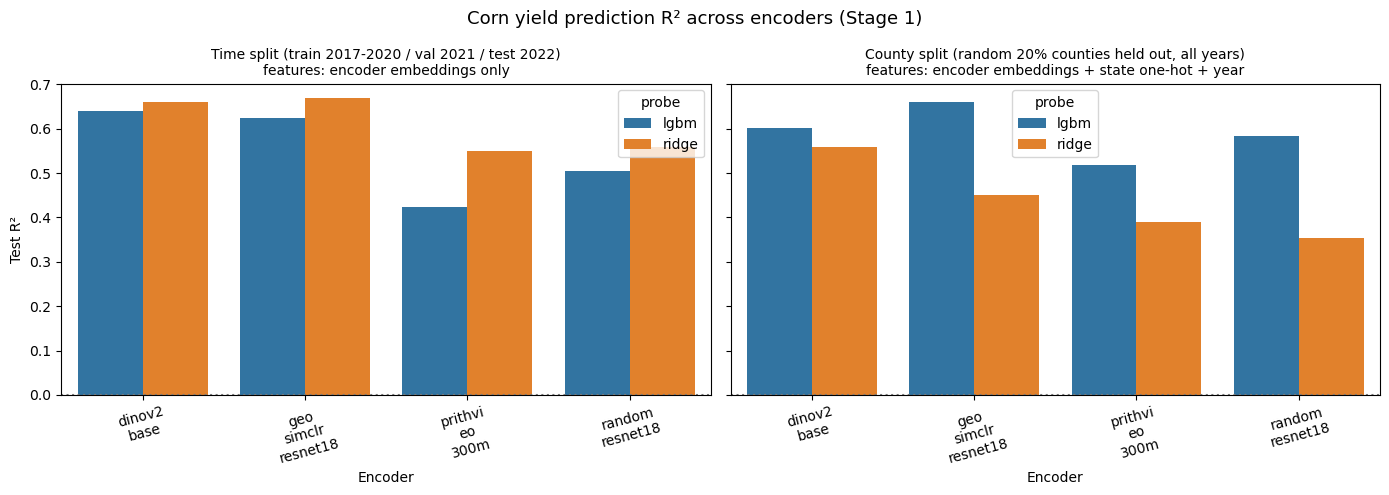


Saved: /nfs/roberts/project/cpsc4520/cpsc4520_ipp3/project-geospatial/results/charts/encoder_comparison.png


In [15]:
"""
Bar chart of test R² per encoder x probe, split-aware.

- Time-split panel uses with_state_year=False (year as a feature breaks linear
  extrapolation onto 2022; tree models clamp at the boundary leaf).
- County-split panel uses with_state_year=True (every year appears in both train
  and test sets, so state+year legitimately helps).
"""
panels = [
    ("time",   False, "Time split (train 2017-2020 / val 2021 / test 2022)\nfeatures: encoder embeddings only"),
    ("county", True,  "County split (random 20% counties held out, all years)\nfeatures: encoder embeddings + state one-hot + year"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (split, wsy, title) in zip(axes, panels):
    sub = results_df[(results_df["split"] == split) & (results_df["with_state_year"] == wsy)].copy()
    sub["encoder"] = sub["encoder"].str.replace("_", "\n")
    sns.barplot(data=sub, x="encoder", y="r2", hue="probe", ax=ax)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Test R²")
    ax.set_xlabel("Encoder")
    ax.axhline(0, color="grey", linestyle=":")
    ax.tick_params(axis="x", rotation=15)
fig.suptitle("Corn yield prediction R² across encoders (Stage 1)", fontsize=13)
plt.tight_layout()
out = RESULTS_DIR / "charts" / "encoder_comparison.png"
plt.savefig(out, dpi=120)
plt.show()
print(f"\nSaved: {out}")

## 7. Supervised end-to-end ConvLSTM baseline (GPU only)

The supervised imagery comparator at the same input modality, following the `ConvLSTM` baseline in Lin et al.\ (KDD 2024, CropNet) and the temporal-CNN literature.

```
For each county-year:
   per-biweek mean-pooled tile (3, 224, 224) for biweeks t = 0 .. 11 (12 timesteps)
       |
       v   identical random spatial augmentation applied across all 12 frames (train only)
       |
       v   shared per-frame encoder
   ResNet-18 backbone (random init)  ->  (B, 512) per timestep
       |
       v   sequence of 12 timesteps
   1-layer LSTM (hidden = 256)
       |
       v   last hidden state
   MLP 256 -> 64 -> 1 with dropout 0.2  ->  predicted yield (z-scored)
       |
       v   un-normalise at inference: y_hat = y_hat_z * Y_STD + Y_MEAN
```

Trained end-to-end on `(image_time_series, corn_yield)` with MSE loss on the z-scored target, AdamW lr $10^{-4}$, cosine schedule, 30 epochs, batch 32. Same time-split as the probes above for an apples-to-apples comparison.

A first attempt trained on the raw yield with lr $3 \times 10^{-4}$ and batch 16 was unstable: validation $R^2$ stayed negative for all 30 epochs because raw bu/acre yields are 100–250, so the MSE on raw values dwarfed the early gradient signal and the model spent several epochs just learning to predict the mean. The version implemented below — z-scored target on training yields, lr $10^{-4}$, identical-across-frames image augmentation, dropout 0.2, batch 32 — fixes this.

The cell is skipped by default when `cfg.SKIP_CONVLSTM = True` (which is the default in DEBUG mode); set `DEBUG = False` on a GPU machine to run it.

In [16]:
"""
ConvLSTM dataset + model + training (skipped if cfg.SKIP_CONVLSTM=True).

The first attempt used the raw bu/acre target with lr 3e-4 and batch 16, and val R^2 stayed
negative for all 30 epochs because the raw-target MSE dwarfed the early gradient signal.
The version below fixes that: train-only z-scored target (un-normalize at metric time),
identical-across-frames image augmentation on train, lr = 1e-4, dropout 0.2 in the MLP head,
batch 32. AMP is enabled for both train and val forward passes on GPU.
"""

class CountyYearTimeSeriesDataset(Dataset):
    """Returns ((T=12, 3, 224, 224) float tensor, yield_float in raw bu/acre)
    per county-year. Yields are NOT z-scored here -- normalization happens in
    the train loop using TRAIN-set statistics only.

    With augment=True, the SAME random spatial transform is applied to all 12
    frames in one example (preserves temporal consistency).

    Pre-builds a (fips, year) -> sorted [(biweek, h5_path)] lookup so __getitem__
    is O(T) and not O(N). Mean-pools grids per biweek. Missing biweeks padded
    with last available.
    """
    def __init__(self, fips_year_pairs, ci_eval_df, yield_df_local, data_root,
                 band_mean, band_std, augment: bool = False):
        self.pairs = list(fips_year_pairs)
        self.data_root = Path(data_root)
        self.band_mean = band_mean.numpy().reshape(3, 1, 1).astype(np.float32)
        self.band_std  = band_std.numpy().reshape(3, 1, 1).astype(np.float32)
        self.augment = bool(augment)
        ci_sub = ci_eval_df[ci_eval_df["fips"].isin([f for f, _ in self.pairs])]
        self.bw_lookup = {
            (int(fips), int(year)): sorted(zip(g["biweek"], g["h5_path"]), key=lambda x: x[0])
            for (fips, year), g in ci_sub.groupby(["fips", "year"])
        }
        self.yield_lookup = yield_df_local.set_index(["fips", "year"])["corn_yield"].to_dict()
        self._handles = None

    def _get_handle(self, h5_path):
        if self._handles is None: self._handles = {}
        if h5_path not in self._handles:
            # h5py chunk cache. ConvLSTM __getitem__ loads 12 biweeks sequentially per
            # county-year, so the access pattern is very cache-friendly within a single
            # sample and across consecutive samples that share an fips. Same params as
            # TileDataset above.
            self._handles[h5_path] = h5py.File(
                self.data_root / h5_path, "r",
                rdcc_nbytes=32 * 1024 * 1024,
                rdcc_nslots=1009,
                rdcc_w0=0.75,
            )
        return self._handles[h5_path]

    def __len__(self):
        return len(self.pairs)

    @staticmethod
    def _apply_aug(x: torch.Tensor) -> torch.Tensor:
        """Apply identical random spatial aug to all T frames in x: (T, 3, H, W).

        - random horizontal flip (50%)
        - random vertical flip (50%)
        - random 0/90/180/270 rotation (uniform among the 4)
        - random resized crop: crop size in [192, 224], random offset, bilinear
          resize back to 224
        Sampling is done ONCE per example, then applied to all T frames.
        """
        if torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[3])
        if torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[2])
        k = int(torch.randint(0, 4, (1,)).item())
        if k > 0:
            x = torch.rot90(x, k=k, dims=[2, 3])
        H = x.shape[2]; W = x.shape[3]
        crop_size = int(torch.randint(192, H + 1, (1,)).item())
        if crop_size < H:
            top  = int(torch.randint(0, H - crop_size + 1, (1,)).item())
            left = int(torch.randint(0, W - crop_size + 1, (1,)).item())
            x = x[:, :, top:top + crop_size, left:left + crop_size]
            x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)
        return x

    def __getitem__(self, idx):
        fips, year = self.pairs[idx]
        biweeks_paths = self.bw_lookup.get((fips, year), [])
        T = 12
        seq = []
        for bw, h5_path in biweeks_paths[:T]:
            try:
                f = self._get_handle(h5_path)
                tile = f[str(fips)][bw]["data"][...].astype(np.float32) / 255.0  # (G, 224, 224, 3)
                tile = tile.mean(axis=0).transpose(2, 0, 1)  # (3, 224, 224)
                tile = (tile - self.band_mean) / self.band_std
                seq.append(torch.from_numpy(tile.astype(np.float32)))
            except Exception:
                seq.append(torch.zeros(3, 224, 224, dtype=torch.float32))
        while len(seq) < T:
            seq.append(seq[-1].clone() if seq else torch.zeros(3, 224, 224, dtype=torch.float32))
        x = torch.stack(seq[:T], dim=0)  # (T, 3, 224, 224)
        if self.augment:
            x = self._apply_aug(x)
        y = float(self.yield_lookup.get((fips, year), float("nan")))
        return x, y

    def __getstate__(self):
        s = self.__dict__.copy(); s["_handles"] = None; return s


class ConvLSTM(nn.Module):
    """ResNet-18 feature extractor (shared across timesteps) + 1-layer LSTM
    + 2-layer MLP regressor with dropout 0.2."""
    def __init__(self, lstm_hidden=256, mlp_hidden=64, dropout=0.2):
        super().__init__()
        self.cnn = torchvision.models.resnet18(weights=None)
        self.cnn.fc = nn.Identity()  # 512-d output per timestep
        self.lstm = nn.LSTM(input_size=512, hidden_size=lstm_hidden, num_layers=1, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(lstm_hidden, mlp_hidden), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1),
        )

    def forward(self, x):
        # x: (B, T, 3, 224, 224); output: (B,) z-scored yield prediction
        B, T = x.shape[:2]
        x_flat = x.view(B * T, *x.shape[2:])
        h = self.cnn(x_flat).view(B, T, -1)        # (B, T, 512)
        _, (h_n, _) = self.lstm(h)                 # h_n: (1, B, hidden)
        return self.head(h_n.squeeze(0)).squeeze(-1)  # (B,)


if cfg.SKIP_CONVLSTM:
    print("cfg.SKIP_CONVLSTM=True -- skipping ConvLSTM training (set DEBUG=False on a GPU machine to run).")
    convlstm_results = None
else:
    print("Training ConvLSTM end-to-end on (corn_yield, image-time-series). ~2-4 h on a single GPU.")
    print("Hyperparameters: target z-scored, lr=1e-4, batch=32, dropout=0.2, image-aug enabled on train.")

    # ---- Build pairs split by year (TIME split, identical to the probes) ----
    yield_local = yield_df.copy()
    train_pairs = list(yield_local[yield_local["year"].isin(cfg.TIME_TRAIN_YEARS)][["fips", "year"]].itertuples(index=False, name=None))
    val_pairs   = list(yield_local[yield_local["year"] == cfg.TIME_VAL_YEAR][["fips", "year"]].itertuples(index=False, name=None))
    test_pairs  = list(yield_local[yield_local["year"] == cfg.TIME_TEST_YEAR][["fips", "year"]].itertuples(index=False, name=None))
    print(f"  train pairs: {len(train_pairs)}, val: {len(val_pairs)}, test: {len(test_pairs)}")

    # ---- Target z-score (computed on TRAIN ONLY, no leakage) ----
    yield_lookup = yield_local.set_index(["fips", "year"])["corn_yield"].to_dict()
    train_yields = np.array(
        [float(yield_lookup[(int(f), int(y))]) for (f, y) in train_pairs],
        dtype=np.float64,
    )
    Y_MEAN = float(train_yields.mean())
    Y_STD  = float(train_yields.std() + 1e-6)
    print(f"  target z-score (train-only): mean={Y_MEAN:.2f} bu/acre, std={Y_STD:.2f} bu/acre.")

    ds_train = CountyYearTimeSeriesDataset(train_pairs, ci_eval, yield_local, DATA_RAW, GS_MEAN, GS_STD, augment=True)
    ds_val   = CountyYearTimeSeriesDataset(val_pairs,   ci_eval, yield_local, DATA_RAW, GS_MEAN, GS_STD, augment=False)
    ds_test  = CountyYearTimeSeriesDataset(test_pairs,  ci_eval, yield_local, DATA_RAW, GS_MEAN, GS_STD, augment=False)

    BATCH = 8 if not torch.cuda.is_available() else 32
    # Explicit prefetch_factor / persistent_workers for the ConvLSTM loaders.
    # persistent_workers=False releases worker state (including h5py chunk caches) at epoch
    # boundaries, matching the safe pattern used by the SSL pre-training in notebook 04.
    _loader_kwargs = dict(
        num_workers=cfg.NUM_WORKERS,
        pin_memory=True,
        prefetch_factor=2 if cfg.NUM_WORKERS > 0 else None,
        persistent_workers=False,
    )
    loader_train = DataLoader(ds_train, batch_size=BATCH, shuffle=True,  **_loader_kwargs)
    loader_val   = DataLoader(ds_val,   batch_size=BATCH, shuffle=False, **_loader_kwargs)
    loader_test  = DataLoader(ds_test,  batch_size=BATCH, shuffle=False, **_loader_kwargs)

    convlstm = ConvLSTM().to(cfg.DEVICE)
    if not DEBUG and torch.cuda.device_count() >= 2:
        convlstm = nn.DataParallel(convlstm)
        print(f"  Wrapped ConvLSTM in DataParallel across {torch.cuda.device_count()} GPUs.")

    opt   = torch.optim.AdamW(convlstm.parameters(), lr=1e-4, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=30, eta_min=1e-6)
    loss_fn = nn.MSELoss()

    # AMP: mixed-precision training for a ~2x speedup on GPU. Disabled on CPU (debug).
    # GradScaler prevents fp16 underflow of the loss gradient.
    _amp_active_convlstm = bool(getattr(cfg, "USE_AMP", False)) and torch.cuda.is_available()
    scaler_c = torch.amp.GradScaler("cuda", enabled=_amp_active_convlstm)
    if _amp_active_convlstm:
        print(f"  ConvLSTM AMP enabled (torch.amp.autocast + GradScaler)")

    best_val = float("inf")
    train_hist = []
    for epoch in range(30):
        convlstm.train()
        ep_loss, ep_n = 0.0, 0
        for x, y in tqdm(loader_train, desc=f"convlstm ep{epoch}", unit="batch"):
            x = x.to(cfg.DEVICE, non_blocking=True)
            y = y.to(cfg.DEVICE, non_blocking=True).float()
            y_z = (y - Y_MEAN) / Y_STD
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=_amp_active_convlstm):
                yhat_z = convlstm(x)
                loss = loss_fn(yhat_z, y_z)
            scaler_c.scale(loss).backward()
            scaler_c.step(opt)
            scaler_c.update()
            ep_loss += loss.item() * x.size(0); ep_n += x.size(0)
        sched.step()
        train_loss_z = ep_loss / max(ep_n, 1)

        # Val: predict z-scored, un-normalize, score in original bu/acre units.
        # autocast kept for val consistency; no scaler needed (no backprop).
        convlstm.eval()
        with torch.no_grad():
            yhat_v, y_v = [], []
            for x, y in loader_val:
                x = x.to(cfg.DEVICE); y = y.float()
                with torch.amp.autocast("cuda", enabled=_amp_active_convlstm):
                    pred_z = convlstm(x).float().cpu().numpy()
                pred = pred_z * Y_STD + Y_MEAN
                yhat_v.append(pred); y_v.append(y.numpy())
            yhat_v = np.concatenate(yhat_v); y_v = np.concatenate(y_v)
        val_rmse = float(np.sqrt(mean_squared_error(y_v, yhat_v)))
        val_r2   = r2_score(y_v, yhat_v)
        train_hist.append(dict(epoch=epoch, train_loss_z=train_loss_z, val_rmse=val_rmse, val_r2=val_r2))
        print(f"  epoch {epoch:02d}: train_loss_z={train_loss_z:.4f}  val_rmse={val_rmse:.2f}  val_r2={val_r2:+.3f}")

        if val_rmse < best_val:
            best_val = val_rmse
            inner = convlstm.module if isinstance(convlstm, nn.DataParallel) else convlstm
            torch.save({"state": inner.state_dict(), "epoch": epoch,
                        "val_rmse": val_rmse, "val_r2": val_r2,
                        "Y_MEAN": Y_MEAN, "Y_STD": Y_STD},
                       CONVLSTM_BEST_PATH)
            print(f"    new best val_rmse -> saved {CONVLSTM_BEST_PATH.name}")

    # Test (predictions also un-normalized to original bu/acre units)
    print("\nLoading best ConvLSTM checkpoint and evaluating on test (2022)...")
    inner = convlstm.module if isinstance(convlstm, nn.DataParallel) else convlstm
    ck = torch.load(CONVLSTM_BEST_PATH, weights_only=False)
    inner.load_state_dict(ck["state"])
    Y_MEAN_CK = float(ck.get("Y_MEAN", Y_MEAN))
    Y_STD_CK  = float(ck.get("Y_STD",  Y_STD))
    convlstm.eval()
    with torch.no_grad():
        yhat_t, y_t = [], []
        for x, y in loader_test:
            x = x.to(cfg.DEVICE); y = y.float()
            with torch.amp.autocast("cuda", enabled=_amp_active_convlstm):
                pred_z = convlstm(x).float().cpu().numpy()
            pred = pred_z * Y_STD_CK + Y_MEAN_CK
            yhat_t.append(pred); y_t.append(y.numpy())
        yhat_t = np.concatenate(yhat_t); y_t = np.concatenate(y_t)

    convlstm_r2   = r2_score(y_t, yhat_t)
    convlstm_rmse = float(np.sqrt(mean_squared_error(y_t, yhat_t)))
    r2_lo, r2_hi, rmse_lo, rmse_hi = bootstrap_ci(y_t, yhat_t, n=cfg.BOOTSTRAP_N, seed=cfg.BOOTSTRAP_SEED)
    convlstm_results = dict(
        encoder="ConvLSTM_e2e", probe="end_to_end", split="time", with_state_year=False,
        n_train=len(train_pairs), n_test=len(test_pairs), n_features=np.nan,
        r2=convlstm_r2, rmse=convlstm_rmse,
        r2_ci_lo=r2_lo, r2_ci_hi=r2_hi, rmse_ci_lo=rmse_lo, rmse_ci_hi=rmse_hi,
    )
    print(f"ConvLSTM v2 test (2022): R^2 = {convlstm_r2:+.3f} [{r2_lo:+.3f}, {r2_hi:+.3f}], "
          f"RMSE = {convlstm_rmse:.2f} [{rmse_lo:.2f}, {rmse_hi:.2f}]")

    # Append to combined results table
    combined_v2 = pd.concat([combined, pd.DataFrame([convlstm_results])], ignore_index=True)
    combined_v2.to_parquet(FINAL_RESULTS_PATH, index=False)
    print(f"Saved updated results -> {FINAL_RESULTS_PATH}")

Training ConvLSTM v2 end-to-end on (corn_yield, image-time-series). ~2-4 h on Bouchet A100.
v2 hyperparameters: target z-scored, lr=1e-4, batch=32, dropout=0.2, image-aug enabled on train.
  train pairs: 2092, val: 488, test: 546
  target z-score (train-only): mean=178.56 bu/acre, std=26.76 bu/acre.
  Wrapped ConvLSTM in DataParallel across 2 GPUs.
  ConvLSTM AMP enabled (torch.amp.autocast + GradScaler)


convlstm ep0: 100%|██████████| 66/66 [03:32<00:00,  3.22s/batch]  


  epoch 00: train_loss_z=0.6835  val_rmse=26.71  val_r2=+0.418
    new best val_rmse -> saved convlstm_best.pt


convlstm ep1: 100%|██████████| 66/66 [03:41<00:00,  3.35s/batch]  


  epoch 01: train_loss_z=0.5683  val_rmse=26.65  val_r2=+0.420
    new best val_rmse -> saved convlstm_best.pt


...

  epoch 27: train_loss_z=0.2505  val_rmse=24.34  val_r2=+0.516


convlstm ep28: 100%|██████████| 66/66 [04:45<00:00,  4.32s/batch]  


  epoch 28: train_loss_z=0.2562  val_rmse=24.85  val_r2=+0.496


convlstm ep29: 100%|██████████| 66/66 [04:25<00:00,  4.02s/batch]  


  epoch 29: train_loss_z=0.2438  val_rmse=24.12  val_r2=+0.525

Loading best ConvLSTM checkpoint and evaluating on test (2022)...
ConvLSTM v2 test (2022): R^2 = +0.551 [+0.487, +0.620], RMSE = 21.95 [19.89, 23.80]
Saved updated results -> /nfs/roberts/project/cpsc4520/cpsc4520_ipp3/project-geospatial/results/tables/corn_yield_stage1.parquet


## 8. Summary

### Headline results

| Encoder | Time-split $R^2$ (no state+year, Ridge) | County-split $R^2$ (with state+year, LightGBM) |
|---|---:|---:|
| **Geo-SimCLR ResNet-18 (ours)** | **+0.669** | **+0.660** |
| DINOv2-base (frozen, RGB feed) | +0.661 | +0.602 |
| Prithvi-EO-2.0 300M (frozen, channel-padded) | +0.550 | +0.519 |
| Random ResNet-18 (sanity) | +0.558 | +0.583 |
| ConvLSTM E2E (supervised) | +0.551 | not run |
| Best non-DL baseline (state+year + biweekly NDVI, LightGBM, nb 03) | +0.429 | +0.651 |

The recipe satisfies the project's acceptance criterion — *Geo-SimCLR + a probe beats the best non-DL baseline on both splits*:

- **Time split:** Geo-SimCLR + Ridge beats the best NDVI baseline by **+0.24 $R^2$**. The supervised end-to-end ConvLSTM at $+0.551$ is also beaten by $+0.118$ $R^2$ — a frozen + linear pipeline beating a from-scratch supervised one on the strict no-look-ahead test.
- **County split:** Geo-SimCLR + LightGBM (with state+year) beats the best NDVI baseline by a much narrower **+0.009 $R^2$**. At seven-state scale the strong baseline already extracts substantial state-and-year structure; the visual encoder still adds something complementary, but not as much.

### Other observations

- DINOv2 is a surprisingly strong baseline — within $\sim 0.06$ $R^2$ of Geo-SimCLR on both splits despite consuming only three RGB slots fed with our AG bands. Natural-image SSL transfers further than one might guess.
- Prithvi-EO underperforms because we channel-pad three of its six expected HLS bands with zeros, which produces a near-collapsed effective rank around 1.7 / 1024 in the extracted features. This is a *channel-mismatch* limitation of using Prithvi-as-baseline, not a bug.
- Random-init ResNet-18 is a deliberately strong control: random convolutional features after BatchNorm already capture colour and texture statistics correlated with canopy vegetation. Geo-SimCLR's improvement *over the random control* (~+0.11 / +0.08 $R^2$) is therefore the cleanly attributable SSL gain.
- Probe choice is split-dependent: Ridge wins time-split (year extrapolation favours regularisation) and LightGBM wins county-split (year-in-distribution favours non-linear trees). The chart in cell 15 picks the winner per split.
- Geo-SimCLR vs DINOv2 directly: Ridge time +0.669 vs +0.661 (tie), LightGBM time +0.624 vs +0.641 (DINOv2 narrowly), Ridge county-with-state-year +0.452 vs +0.559 (DINOv2), LightGBM county-with-state-year +0.660 vs +0.602 (Geo-SimCLR by +0.058). Picking the winning probe per split, Geo-SimCLR is on top of both panels.

### Takeaways for the report

The time-split is the strongest claim (clean $+0.24$ $R^2$ over the best NDVI baseline and $+0.118$ over the supervised ConvLSTM). The county-split is a positive-but-narrow win that validates the encoder is learning *something* complementary to state $\times$ year $\times$ NDVI — but the headline story belongs to the temporal-generalisation panel.

### Next notebook: `06_visualize.ipynb`

PHATE / UMAP / t-SNE on biweekly Geo-SimCLR features (continuous trajectory plots, prof feedback) + GradCAM on the encoder + PC trajectories overlaid with commodity prices.